# Biome estimation exercise

Below you will 

In [1]:
import pandas as pd
import cartopy.crs as ccrs # Enables geographic mapping, e.g., drawing coastlines, etc
import matplotlib.pyplot as plt


proj = ccrs.PlateCarree()

In [21]:
def format_rbg_string(rgbstring):
    """Transform a RGB string to a tuple of floats that matplotlib can understand"""
    rgbs = rgbstring.split(' ')
    rgbtup = tuple(float(rgb) for rgb in rgbs)
    return rgbtup

with open('legend of biomes.txt', 'r') as f:
    lines = [ l.strip() for l in f.readlines()] # Remove endline characters and spaces
    
biome_names = lines[slice(0, len(lines), 2)] # Only use the biome names, not the colors
biome_names = [ ' '.join(l.split(' ')[1:]) for l in biome_names ] # Remove number in front of names
biome_rgbs = lines[slice(1, len(lines), 2)] # Filter out biome RGB colors
biome_rgbs = [format_rbg_string(rgbstr) for rgbstr in biome_rgbs]
biome_names

['Boreal decid forest',
 'Boreal ever forest',
 'Temp/boreal mix fo.',
 'Temp conifer forest',
 'Temp decid forest',
 'Temp broad ever fo.',
 'Temp mixed forest',
 'Trop season forest',
 'Trop rain forest',
 'Trop decid forest',
 'Moist savannas',
 'Dry savannas',
 'Tall grassland',
 'Dry grassland',
 'Xeric wood/shrub',
 'Arid shrub/steppe',
 'Desert',
 'Arctic/alpine tundra']

In [64]:
countries = pd.read_csv('gridlist_pan_gfed_ISO3_UN.txt', sep='\\s+')
countries.head()

,Lon,Lat,GFED-region,Pan_2007,ISO3,UN
0,-69.75,-55.25,5,Americas,CHL,152
1,-69.25,-55.25,5,Americas,CHL,152
2,-71.25,-54.75,5,Americas,CHL,152
3,-70.75,-54.75,5,Americas,CHL,152
4,-70.25,-54.75,5,Americas,CHL,152


In [4]:
# Biome obs from Haxeltine & Prentice, 1996
df = pd.read_csv('data/LPJ-GUESS_output_BERN1.csv')
df.head()

,Lon,Lat,NPP,SoilR,MaxBiomeCmax,MaxBiomeLAI,VegC,LitterC,SoilC,Biome_Cmax,Biome_LAI,Biome_obs
0,39.75,-1.25,0.429,0.390,0.449,1.9821,1.225,0.758,5.941,8,12,12
1,150.25,-34.25,0.554,0.451,6.883,3.3174,6.953,3.221,10.566,7,7,6
2,-63.75,82.75,0.000,0.000,0.000,0.0000,0.000,0.003,0.002,13,13,17
3,59.25,30.75,0.043,0.042,0.090,0.2146,0.127,0.084,0.543,7,11,14
4,24.25,27.75,0.000,0.000,0.000,0.0000,0.000,0.000,0.000,13,13,17


In [5]:
biome_data = df[['Lon', 'Lat', 'Biome_obs']]
biome_data['Biome_obs'].value_counts()

Biome_obs
2     11118
17     6505
9      5924
18     5725
16     4577
14     3965
5      3962
12     3643
15     3134
6      2748
8      2560
10     1702
1      1383
11     1027
3       734
13      367
7       117
Name: count, dtype: int64

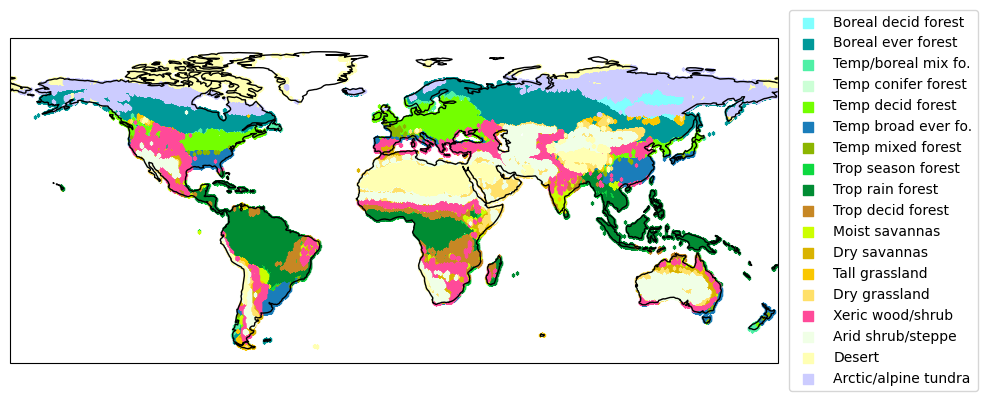

In [62]:
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw=dict(projection=proj))

# Hacky way of creating a map, pretent it is a scatterplot with lons and lats on x and y!
for i, name in enumerate(biome_names):
    biome = biome_data[biome_data['Biome_obs'] == i +1]
    biome.plot(x='Lon', y='Lat', color=biome_rgbs[i], ax=ax, kind='scatter', s=.6, label=name, marker=',')


ax.legend(markerscale=10, loc='center right', bbox_to_anchor=(1.27, .5)) # Make markers bigger
ax.coastlines()
plt.tight_layout()
plt.show()

# Start your data formatting below. Good luck!